## MATH 529L Worksheet 8 - Nathan Day

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from numpy.linalg import eigvals

In [ ]:
from IPython.display import display, Math, HTML

def h(txt: str):
    display(HTML(f"<div style='font-size:16px; line-height:1.35'>{txt}</div>"))

def title(txt: str):
    display(HTML(f"<div style='font-size:28px; font-weight:700; margin:10px 0 6px 0'>{txt}</div>"))

def section(txt: str):
    display(HTML(f"<div style='font-size:22px; font-weight:700; margin:14px 0 6px 0'>{txt}</div>"))

def problem(txt: str):
    display(HTML(f"<div style='font-size:18px; font-weight:700; margin:10px 0 4px 0'>Problem {txt}</div>"))

def eq(latex: str):
    display(Math(latex))

In [ ]:
section("1.1 Analysis of Turing System")

h("We consider the reaction–diffusion system on 0 < x < L:")
eq(r"u_t=\alpha u_{xx}+f(u,v), \qquad v_t=\beta v_{xx}+g(u,v)")

h("with no-flux (Neumann) boundary conditions:")
eq(r"u_x(0,t)=u_x(L,t)=0, \qquad v_x(0,t)=v_x(L,t)=0")

h("Let (ū, v̄) be an equilibrium and define perturbations:")
eq(r"u=\overline{u}+U(x,t), \qquad v=\overline{v}+V(x,t)")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
problem("1.1(a)")

h("Boundary conditions for the perturbations U,V:")
eq(r"u_x = (\overline{u})_x + U_x = U_x,\qquad v_x = (\overline{v})_x + V_x = V_x")
eq(r"U_x(0,t)=U_x(L,t)=0,\qquad V_x(0,t)=V_x(L,t)=0")

h("Linearization about the equilibrium (drop higher-order terms):")
eq(r"U_t=\alpha U_{xx}+f_u(\overline{u},\overline{v})\,U+f_v(\overline{u},\overline{v})\,V")
eq(r"V_t=\beta V_{xx}+g_u(\overline{u},\overline{v})\,U+g_v(\overline{u},\overline{v})\,V")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
problem("1.1(b)")

h("We have to use matrix notation and rewrite the linearized system in matrix form.")

# Define w, D, J
eq(r"w=\begin{pmatrix}U\\V\end{pmatrix}")
eq(r"D=\begin{pmatrix}\alpha&0\\0&\beta\end{pmatrix}")
eq(r"J=\begin{pmatrix}f_u(\overline{u},\overline{v}) & f_v(\overline{u},\overline{v})\\ g_u(\overline{u},\overline{v}) & g_v(\overline{u},\overline{v})\end{pmatrix}")

# Now how does the matrix products match the scalar equations
h("Check the products:")

eq(r"w_t=\begin{pmatrix}U_t\\V_t\end{pmatrix},\qquad w_{xx}=\begin{pmatrix}U_{xx}\\V_{xx}\end{pmatrix}")

eq(r"D\,w_{xx}=\begin{pmatrix}\alpha&0\\0&\beta\end{pmatrix}\begin{pmatrix}U_{xx}\\V_{xx}\end{pmatrix}=\begin{pmatrix}\alpha U_{xx}\\ \beta V_{xx}\end{pmatrix}")

eq(r"J\,w=\begin{pmatrix}f_u&f_v\\ g_u&g_v\end{pmatrix}\begin{pmatrix}U\\V\end{pmatrix}=\begin{pmatrix}f_u U+f_v V\\ g_u U+g_v V\end{pmatrix}")

# Final matrix form
h("Therefore the linearized system can be written in matrix form as:")
eq(r"w_t = D\,w_{xx} + J\,w")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
problem("1.1(c)")

h("Assume a Neumann eigenfunction mode:")
eq(r"w(x,t)=c\,e^{\sigma_n t}\cos\!\left(\frac{n\pi x}{L}\right),\qquad n=0,1,2,\dots")
eq(r"w_{xx}=-\left(\frac{n\pi}{L}\right)^2 c\,e^{\sigma_n t}\cos\!\left(\frac{n\pi x}{L}\right)")
eq(r"\sigma_n c = \left(J-\left(\frac{n\pi}{L}\right)^2D\right)c")
eq(r"\det\!\left(J-\left(\frac{n\pi}{L}\right)^2D-\sigma_n I\right)=0")

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
problem("1.1(d)")

h("Physical interpretation of σₙ:")

eq(r"w(x,t)=c\,e^{\sigma_n t}\cos\!\left(\frac{n\pi x}{L}\right)")

h("The quantity σₙ is the growth rate of the spatial mode n.")

h("• If Re(σₙ) > 0, the mode grows exponentially in time, meaning that small perturbations amplify and patterns form.")

h("• If Re(σₙ) < 0, the mode decays and the perturbation disappears, so the system returns to the equilibrium.")

h("• If σₙ is complex, the perturbation oscillates in time, but the sign of Re(σₙ) still determines whether it grows or decays.")

<IPython.core.display.Math object>

In [ ]:
section("1.2 Specific Turing Model")
# I am sorry I couldn't figure out how to neatly fix pi :(
h("We now consider the specific system on 0 < x < \\(\\pi\\) with Neumann BCs:")
eq(r"u_t = D u_{xx} + 1 + u^2 v - u")
eq(r"v_t = v_{xx} + 2 - u^2 v")

h("Equilibrium (ū, v̄):")
eq(r"2-u^2v=0 \Rightarrow u^2v=2")
eq(r"1+u^2v-u=0 \Rightarrow 1+2-u=0 \Rightarrow u=3")
eq(r"v = \frac{2}{u^2}=\frac{2}{9}")
eq(r"(\overline{u},\overline{v})=\left(3,\frac{2}{9}\right)")

h("Jacobian J at (ū, v̄):")
eq(r"f(u,v)=1+u^2v-u,\qquad g(u,v)=2-u^2v")
eq(r"f_u=2uv-1,\ f_v=u^2,\ g_u=-2uv,\ g_v=-u^2")
eq(r"J=\begin{pmatrix}\frac13 & 9\\[3pt]-\frac43 & -9\end{pmatrix}")

# I'm hard-coding ubar,vbar,J because we use them in every problem
ubar = 3.0
vbar = 2.0/9.0
J = np.array([[1/3, 9],
              [-4/3, -9]], dtype=float)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:
# For each mode n, I form the matrix M = J - k^2 * diag(D,1)
# and define sigma_n(D) = max(real(eigs(M))).
# If sigma_n(D) > 0 for some n, that means that spatial mode grows -> instability.

def sigma_max_real(D, n, L=np.pi):
    k = (n*np.pi)/L  # for L=pi, k = n
    Dmat = np.diag([D, 1.0])
    M = J - (k**2)*Dmat
    lam = eigvals(M)
    return float(np.max(np.real(lam)))

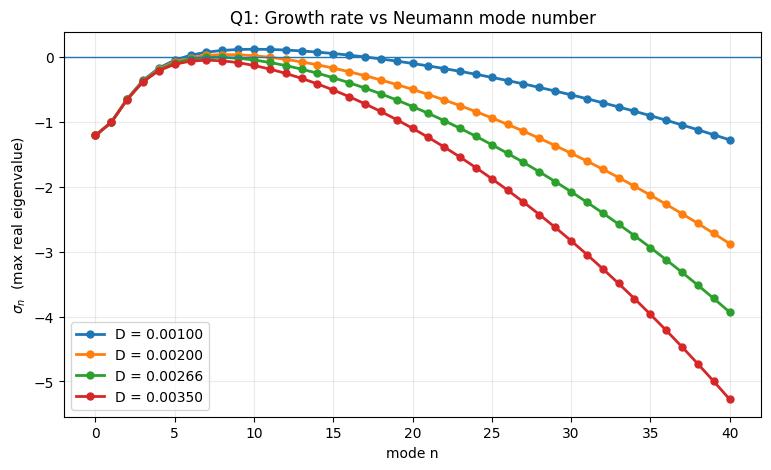

D=0.00100: max sigma = 0.123366 at mode n=10
D=0.00200: max sigma = 0.041042 at mode n=8
D=0.00266: max sigma = -0.001293 at mode n=8
D=0.00350: max sigma = -0.045225 at mode n=7


In [ ]:
section("Q1")

# The worksheet shares the critical Dc around 0.00266.
# So I'm picking D values around that so we can see stable vs unstable behavior
# like we said from the lecture

Dc = 0.00266
D_values = [0.0010, 0.0020, Dc, 0.0035]
labels = [f"D = {D:.5f}" for D in D_values]

n_modes = np.arange(0, 41)  # modes 0..40
sigma_all = np.zeros((len(D_values), len(n_modes)))

for idx, D in enumerate(D_values):
    for j, n in enumerate(n_modes):
        sigma_all[idx, j] = sigma_max_real(D, n)

plt.figure(figsize=(9,5))
for idx, D in enumerate(D_values):
    plt.plot(n_modes, sigma_all[idx], marker='o', linewidth=2, markersize=5, label=labels[idx])

plt.axhline(0, linewidth=1)
plt.xlabel("mode n")
plt.ylabel(r"$\sigma_n$  (max real eigenvalue)")
plt.title("Q1: Growth rate vs Neumann mode number")
plt.legend()
plt.grid(True, alpha=0.25)
plt.show()

# Which mode grows fastest for each D?
for idx, D in enumerate(D_values):
    n_star = int(np.argmax(sigma_all[idx]))
    print(f"D={D:.5f}: max sigma = {sigma_all[idx,n_star]:.6f} at mode n={n_star}")

In [ ]:
problem("1.2(2)")

h("Using the dispersion relation:")

eq(r"\sigma_n = \lambda_{\max}\left(J - k_n^2 D\right)")

h("The value σₙ determines whether the spatial mode n grows or decays.")

h("From the plot in Q1 we observe:")

h("• For D = 0.001 and D = 0.002, some σₙ > 0, meaning those spatial modes grow and the equilibrium becomes unstable.")

h("• Near D ≈ 0.00266, the largest σₙ is approximately zero, which corresponds to the critical diffusion coefficient.")

h("• For D = 0.0035, all σₙ < 0, so all perturbations decay and the equilibrium is stable.")

<IPython.core.display.Math object>

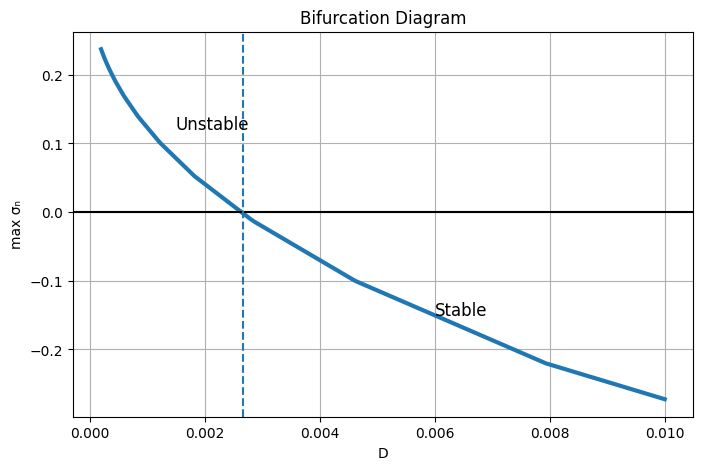

Estimated Dc ≈ 0.002662311557788945


In [ ]:
section("Bifurcation Diagram")

D_scan = np.linspace(0.0002,0.01,200)
max_sigma = []

for D in D_scan:

    sigmas=[]

    for n in range(40):
        sigmas.append(sigma_max_real(D,n))

    max_sigma.append(np.max(sigmas))

max_sigma=np.array(max_sigma)

plt.figure(figsize=(8,5))

plt.plot(D_scan,max_sigma,linewidth=3)

plt.axhline(0,color='black')

plt.xlabel("D")
plt.ylabel("max σₙ")
plt.title("Bifurcation Diagram")

# estimate critical D
Dc = D_scan[np.argmin(np.abs(max_sigma))]

plt.axvline(Dc,linestyle="--")

# labels
plt.text(0.0015,0.12,"Unstable",fontsize=12)
plt.text(0.006,-0.15,"Stable",fontsize=12)

plt.grid(True)

plt.show()

print("Estimated Dc ≈",Dc)

In [ ]:
section("Q2")

from scipy.optimize import brentq

# For each integer mode n, I solve sigma_n(D)=0 for D>0.
# That gives the neutral stability curve D_neutral(n).
# I’m bracketing roots on a positive interval and using brentq.

def find_neutral_D_for_mode(n, D_lo=1e-6, D_hi=0.05):
    f = lambda D: sigma_max_real(D, n)

    # sample to find a sign change
    Ds = np.logspace(np.log10(D_lo), np.log10(D_hi), 200)
    vals = np.array([f(D) for D in Ds])

    # find an interval where it crosses 0
    for i in range(len(Ds)-1):
        if np.sign(vals[i]) == 0:
            return Ds[i]
        if np.sign(vals[i]) != np.sign(vals[i+1]):
            return brentq(f, Ds[i], Ds[i+1], maxiter=200)
    return np.nan

k_vals = np.arange(1, 41)  # modes 1-40 (0 mode is spatially constant based off lecture)
D_neutral = np.array([find_neutral_D_for_mode(int(n)) for n in k_vals])

valid = np.isfinite(D_neutral) & (D_neutral > 0)
k_neutral = k_vals[valid]
D_neutral_valid = D_neutral[valid]

print("Computed neutral D values for modes where a root exists.")
print("First few (k, D):")
for i in range(min(10, len(k_neutral))):
    print(f"k={k_neutral[i]:2d}, D={D_neutral_valid[i]:.6f}")

Computed neutral D values for modes where a root exists.
First few (k, D):
k= 6, D=0.001852
k= 7, D=0.002580
k= 8, D=0.002640
k= 9, D=0.002469
k=10, D=0.002232
k=11, D=0.001992
k=12, D=0.001770
k=13, D=0.001573
k=14, D=0.001402
k=15, D=0.001254


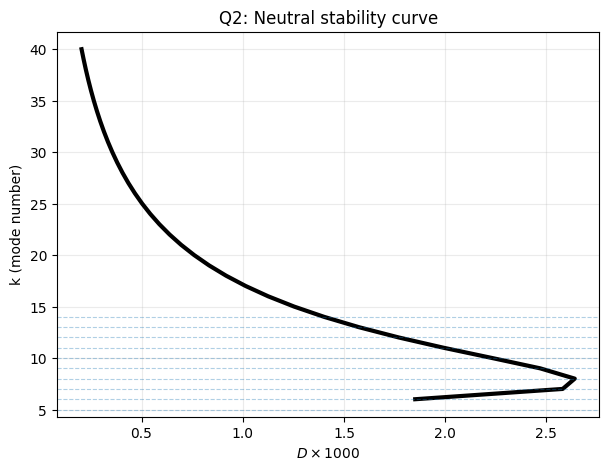

Estimated Dc ~ 0.000204 at k ~ 40


In [ ]:
plt.figure(figsize=(7,5))
plt.plot(D_neutral_valid*1000, k_neutral, 'k-', linewidth=3)
plt.xlabel(r"$D \times 1000$")
plt.ylabel("k (mode number)")
plt.title("Q2: Neutral stability curve")
plt.grid(True, alpha=0.25)

for n in range(5, 15):
    plt.axhline(n, linestyle='--', linewidth=0.8, alpha=0.35)

plt.show()

# I think estimateing Dc as the min of the neutral curve could be nice to see
# to compare for my sake
if len(D_neutral_valid) > 0:
    idx_min = np.argmin(D_neutral_valid)
    print(f"Estimated Dc ~ {D_neutral_valid[idx_min]:.6f} at k ~ {k_neutral[idx_min]}")

In [ ]:
problem("Q2 interpretation")

h("Interpretation of the neutral stability curve:")

eq(r"\sigma_k(D)=0")

h("The curve shows the values of diffusion D and spatial mode number k where the growth rate is zero.")

h("Above the curve all growth rates are negative, so perturbations decay and the homogeneous equilibrium is stable.")

h("Below the curve some modes have positive growth rates, meaning spatial perturbations grow and patterns can form.")

h("The intersections of the horizontal dashed lines with the curve correspond to integer spatial modes that can become unstable.")

h("The lowest point of the curve gives the critical diffusion coefficient D_c where the Turing instability first appears.")

<IPython.core.display.Math object>

In [ ]:
section("Q3")

# I'm discretizing x, approximating u_xx and v_xx with finite differences.
# Neumann BCs get enforced using:
# u_xx(0) = 2*(u1-u0)/dx^2 and u_xx(end)=2*(u_{N-2}-u_{N-1})/dx^2

def laplacian_neumann(w, dx):
    nx = len(w)
    w_xx = np.zeros_like(w)
    # interior
    w_xx[1:-1] = (w[2:] - 2*w[1:-1] + w[:-2]) / dx**2
    # boundaries (Neumann)
    w_xx[0]  = 2*(w[1] - w[0]) / dx**2
    w_xx[-1] = 2*(w[-2] - w[-1]) / dx**2
    return w_xx

def turing_rhs(t, y, D, dx, nx):
    u = y[:nx]
    v = y[nx:]

    u_xx = laplacian_neumann(u, dx)
    v_xx = laplacian_neumann(v, dx)

    f = 1 + u**2 * v - u
    g = 2 - u**2 * v

    du = D*u_xx + f
    dv = 1.0*v_xx + g
    return np.concatenate([du, dv])

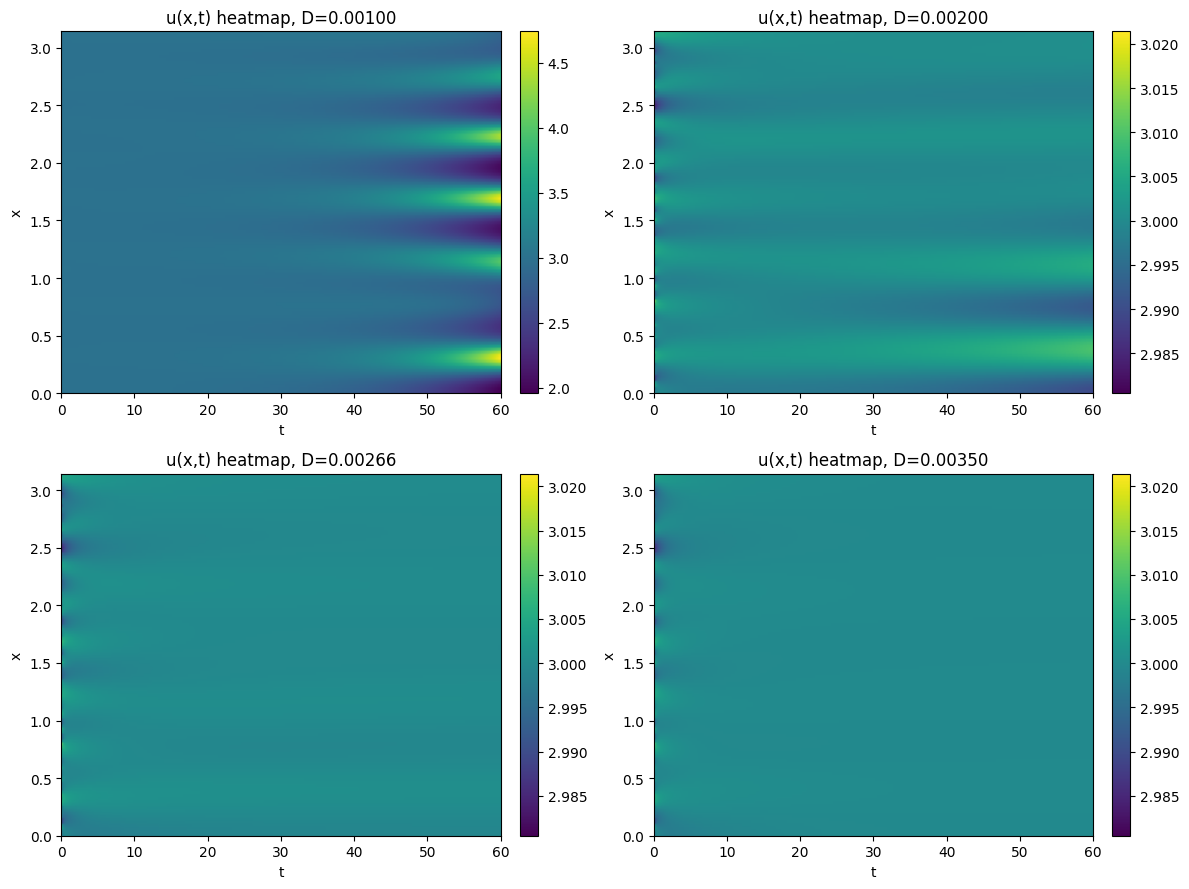

In [ ]:
# Domain and time
L = np.pi
nx = 120
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

t_final = 60.0
t_eval = np.linspace(0, t_final, 500)

# I'm going to pick the same 4 D values as Q1
D_values_Q3 = D_values

plt.figure(figsize=(12,9))

for idx, D in enumerate(D_values_Q3, start=1):
    # I'm starting near equilibrium but with a tiny random perturbation,
    # because we probably want to see whether patterns grow
    rng = np.random.default_rng(42)
    u0 = ubar + 0.01*rng.standard_normal(nx)
    v0 = vbar + 0.01*rng.standard_normal(nx)
    y0 = np.concatenate([u0, v0])

    sol = solve_ivp(
        fun=lambda t, y: turing_rhs(t, y, D, dx, nx),
        t_span=(0, t_final),
        y0=y0,
        t_eval=t_eval,
        method="BDF", # backward difference formula solver
        rtol=1e-6,
        atol=1e-8
    )

    if not sol.success:
        print(f"Solver failed for D={D}: {sol.message}")
        continue

    u_sol = sol.y[:nx, :]

    ax = plt.subplot(2, 2, idx)
    im = ax.imshow(
        u_sol,
        aspect='auto',
        origin='lower',
        extent=[sol.t[0], sol.t[-1], x[0], x[-1]]
    )
    ax.set_title(f"u(x,t) heatmap, D={D:.5f}")
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [ ]:
problem("1.2(3)")

h("Interpretation of the simulations:")

h("When D is below the critical value, small random perturbations grow and form spatial patterns.")

h("This is visible for D = 0.001 and D = 0.002 where stripes emerge in the solution.")

h("When D is above the critical value, perturbations decay and the system returns to the homogeneous equilibrium.")

h("This is observed for D = 0.00266 and D = 0.0035 where the solution becomes uniform in space.")

In [ ]:
# The prompt says I probably need a long run time to actually see the pattern.
# So I'm increasing t_final a lot

t_final_long = 250.0
t_eval_long = np.linspace(0, t_final_long, 800)

# Choose a few D values where Q1 said unstable (pattern) and stable (no pattern)
D_pattern_list = [0.0010, 0.0020]   # should form patterns (unstable)
D_nopattern_list = [0.0035]         # should not form patterns (stable)

D_test = D_pattern_list + D_nopattern_list

nx = 140
L = np.pi
x = np.linspace(0, L, nx)
dx = x[1] - x[0]

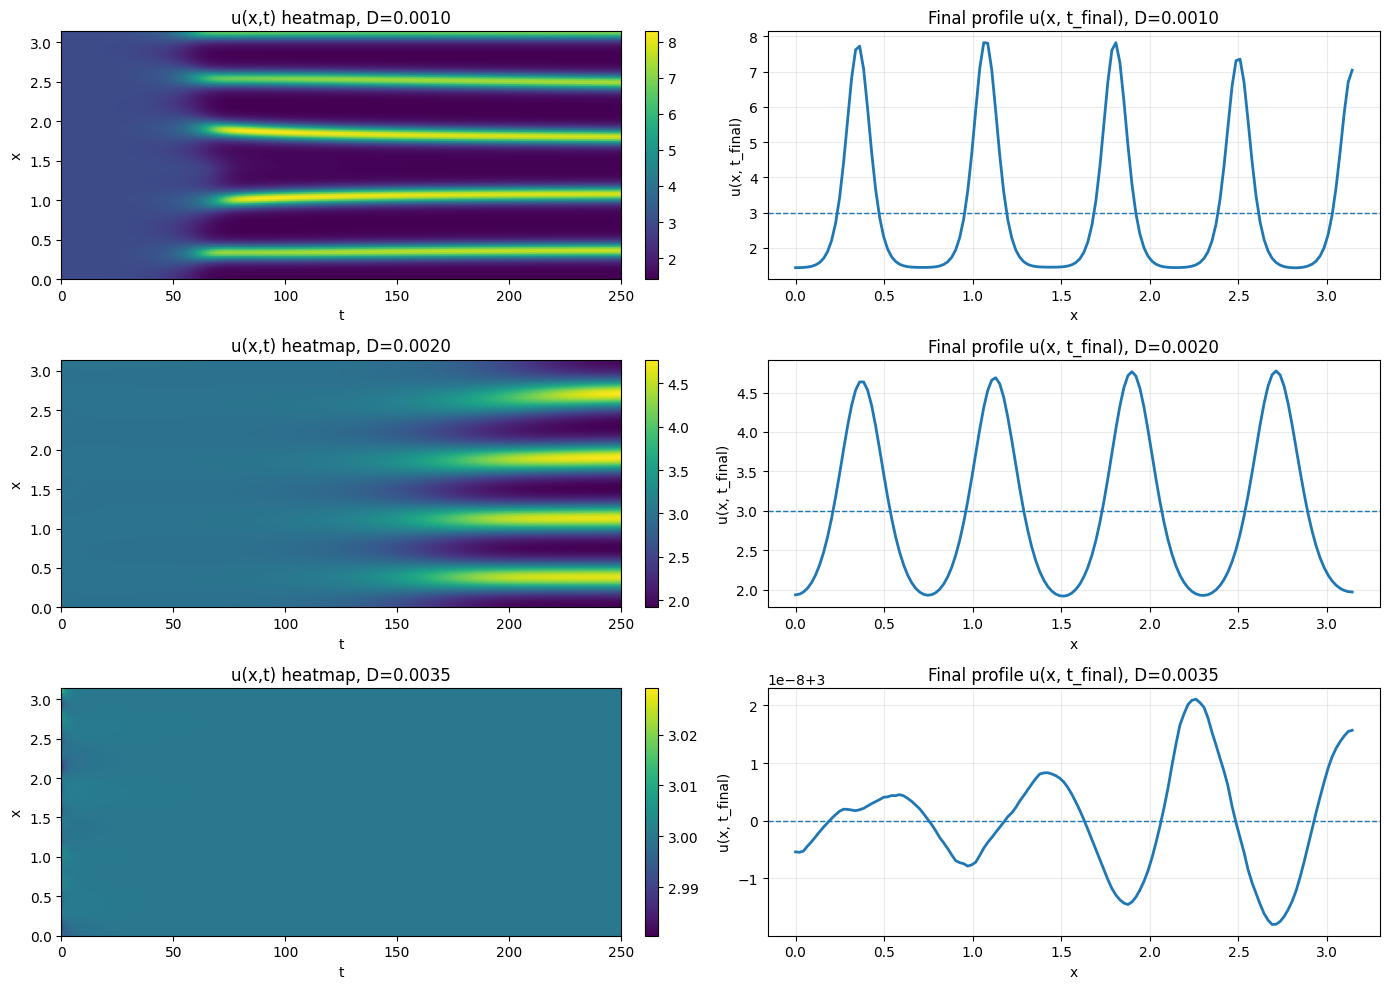

In [ ]:
plt.figure(figsize=(14, 10))

for idx, D in enumerate(D_test, start=1):
    # I start near the equilibrium (ubar,vbar) and add small random noise
    rng = np.random.default_rng(42)
    u0 = ubar + 0.01*rng.standard_normal(nx)
    v0 = vbar + 0.01*rng.standard_normal(nx)
    y0 = np.concatenate([u0, v0])

    sol = solve_ivp(
        fun=lambda t, y: turing_rhs(t, y, D, dx, nx),
        t_span=(0, t_final_long),
        y0=y0,
        t_eval=t_eval_long,
        method="BDF",
        rtol=1e-6,
        atol=1e-8
    )

    u_sol = sol.y[:nx, :]   # (nx, nt)

    ax = plt.subplot(len(D_test), 2, 2*idx-1)
    im = ax.imshow(
        u_sol,
        aspect='auto',
        origin='lower',
        extent=[sol.t[0], sol.t[-1], x[0], x[-1]]
    )
    ax.set_title(f"u(x,t) heatmap, D={D:.4f}")
    ax.set_xlabel("t")
    ax.set_ylabel("x")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax2 = plt.subplot(len(D_test), 2, 2*idx)
    ax2.plot(x, u_sol[:, -1], linewidth=2)
    ax2.axhline(ubar, linestyle="--", linewidth=1)
    ax2.set_title(f"Final profile u(x, t_final), D={D:.4f}")
    ax2.set_xlabel("x")
    ax2.set_ylabel("u(x, t_final)")
    ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

In [ ]:
h("Long-time simulations confirm the Turing instability predicted by the linearization.")

h("For small diffusion values (D = 0.001 and D = 0.002), small random perturbations grow over time and produce spatial patterns in u(x,t).")

h("For larger diffusion (D = 0.0035), all perturbations decay and the solution returns to the homogeneous equilibrium u ≈ 3.")

h("Thus the simulations confirm that patterns emerge for D below the critical value D_c ≈ 0.00266 and disappear for D above it.")